### Thư viện

In [1]:
import torch
import json
from pathlib import Path
from PIL import Image
from transformers import BlipProcessor, BlipForQuestionAnswering
from peft import PeftModel
from deep_translator import GoogleTranslator
from torch.utils.data import DataLoader
import numpy as np
import time, os
import matplotlib.pyplot as plt
import numpy as np


from deep_translator import GoogleTranslator

from VQAEvaluator import VQAEvaluator
from VQA import VQAModel

### Đánh giá mô hình zero-shot

In [2]:
# Đánh giá mô hình zero-shot BLIP trên tập test với VQAEvaluator
from b1_zero_shot import BLIPB1ZeroShot
from VQAEvaluator import VQAEvaluator
import json
import os

# Load test samples
with open("data/test.json", "r", encoding="utf-8") as f:
    test_samples = json.load(f)

# Dự đoán với BLIP zero-shot
blip_model = BLIPB1ZeroShot()
preds = []
refs = []
for item in test_samples:
    img_path = os.path.join("", item["image_path"].replace("\\", os.sep))
    from PIL import Image
    image = Image.open(img_path).convert("RGB")
    result = blip_model.predict(image, item["question"])
    preds.append(result["answer_vi"])
    refs.append(item["answer"])

# Đánh giá bằng VQAEvaluator
vqaeval = VQAEvaluator(device=blip_model.device)
metrics_zs, _, _ = vqaeval.evaluate(
    model=None,
    loader=None,
    model_name="BLIP-ZeroShot",
    preds=preds,
    refs=refs,
    verbose=True
)

Đang tải BLIP trên cuda ...


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Model sẵn sàng.

  Evaluating [BLIP-ZeroShot] on [test]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Metric                    Value
  --------------------------------
  Exact Match (%)            0.33
  BLEU (corpus)              7.64
  BLEU-1                    38.98
  BLEU-2                    27.36
  BLEU-3                    24.65
  BLEU-4                    23.03
  ROUGE-L (%)               20.63
  METEOR (%)                 6.47
  BERTScore-P (%)           31.23
  BERTScore-R (%)           23.78
  BERTScore-F (%)           26.12



### Đánh giá model VQA với B2 fine-tuned

In [2]:
class ViEnTranslator:
    """
    Wrapper GoogleTranslator (deep_translator) — miễn phí, không cần API key.
    Dùng cho cả tiền xử lý dataset lẫn inference.
    """
    def __init__(self):
        self.vi2en = GoogleTranslator(source="vi", target="en")
        self.en2vi = GoogleTranslator(source="en", target="vi")

    def to_english(self, text: str) -> str:
        try:
            return self.vi2en.translate(text) or text
        except Exception:
            return text  # fallback: giữ nguyên nếu lỗi mạng

    def to_vietnamese(self, text: str) -> str:
        try:
            return self.en2vi.translate(text) or text
        except Exception:
            return text


# Khởi tạo translator dùng chung toàn notebook
translator = ViEnTranslator()
print("ViEnTranslator sẵn sàng (GoogleTranslator — miễn phí).")

ViEnTranslator sẵn sàng (GoogleTranslator — miễn phí).


In [ ]:
TEST_JSON_EN = "data/test_en.json"   # cache tiếng Anh

def translate_dataset(json_path: str, output_path: str, trans: ViEnTranslator):
    """
    Dịch question + answer sang tiếng Anh, thêm field question_en / answer_en.
    Lưu kết quả vào output_path. Nếu file đã tồn tại → bỏ qua.
    """
    if os.path.exists(output_path):
        print(f"Cache đã tồn tại, bỏ qua: {output_path}")
        return

    with open(json_path, "r", encoding="utf-8") as f:
        samples = json.load(f)

    print(f"Đang dịch {len(samples)} mẫu từ '{json_path}'...")
    for i, s in enumerate(samples):
        s["question_en"] = trans.to_english(s["question"])
        s["answer_en"] = trans.to_english(s["answer"])

        # Throttle nhẹ mỗi 100 mẫu để tránh bị Google tạm block
        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{len(samples)} đã dịch...")
            time.sleep(1.0)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(samples, f, ensure_ascii=False, indent=2)

    print(f"Đã lưu cache: {output_path} ({len(samples)} mẫu)")



translate_dataset('data/test.json',   TEST_JSON_EN,   translator)
print("\nDịch dataset hoàn tất!")

Cache đã tồn tại, bỏ qua: data/test_en.json

Dịch dataset hoàn tất!


In [7]:
# CELL — Load fine-tuned model từ HuggingFace & Đánh giá

#  1. Config 
HF_REPO = "lpv30/DL-CK"
BASE_MODEL= "Salesforce/blip-vqa-base"
VAL_JSON = "data/test_en.json"   # file đã dịch VI→EN
DATA_ROOT = Path("")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE= 8
MAX_NEW_TOKENS = 50
print(f"Device: {DEVICE}")

#  2. Load processor + fine-tuned model từ HF Hub 
print(f"\nLoading model từ '{HF_REPO}'...")
processor = BlipProcessor.from_pretrained(HF_REPO)

base_model = BlipForQuestionAnswering.from_pretrained(BASE_MODEL)
model_ft= PeftModel.from_pretrained(base_model, HF_REPO)
model_ft= model_ft.to(DEVICE).eval()
print("Load model thành công!")

#  3. Translator (EN → VI cho ground-truth refs) 
en2vi = GoogleTranslator(source="en", target="vi")

def en_to_vi(text: str) -> str:
    try:
        return en2vi.translate(text) or text
    except Exception:
        return text

#  4. Sinh prediction trên val set 
print(f"\nĐọc val set từ '{VAL_JSON}'...")
with open(VAL_JSON, "r", encoding="utf-8") as f:
    samples = json.load(f)

all_preds_vi, all_refs_vi = [], []

print(f"Đang inference {len(samples)} mẫu (batch_size={BATCH_SIZE})...")
for i in range(0, len(samples), BATCH_SIZE):
    batch_samples = samples[i : i + BATCH_SIZE]

    images= []
    questions = []   # tiếng Anh — BLIP cần EN
    refs_vi = []   # ground-truth tiếng Việt

    for s in batch_samples:
        img_path = DATA_ROOT / s["image_path"].replace("\\", "/")
        images.append(Image.open(img_path).convert("RGB"))
        questions.append(s.get("question_en", s["question"]))
        refs_vi.append(s.get("answer", ""))       # giữ nguyên VI gốc

    inputs = processor(
        images=images,
        text=questions,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64,
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model_ft.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=4,
            repetition_penalty=2.0,
            length_penalty=1.2,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )

    for j, ids in enumerate(output_ids):
        ans_en = processor.decode(ids, skip_special_tokens=True)
        ans_vi = en_to_vi(ans_en)          # EN → VI để so với ground-truth VI
        all_preds_vi.append(ans_vi)

    all_refs_vi.extend(refs_vi)

    if (i // BATCH_SIZE + 1) % 20 == 0 or i + BATCH_SIZE >= len(samples):
        print(f"  {min(i + BATCH_SIZE, len(samples))}/{len(samples)} mẫu hoàn tất")

print(f"\nInference xong — {len(all_preds_vi)} predictions")

#  6. Đánh giá với VQAEvaluator ─
# Đảm bảo VQAEvaluator.py đã được upload / import đúng chỗ
import sys
sys.path.append("/content")          # điều chỉnh nếu file ở chỗ khác
from VQAEvaluator import VQAEvaluator

evaluator = VQAEvaluator(
    device=str(DEVICE),
    bertscore_model="vinai/phobert-base",   # PhoBERT cho tiếng Việt
    bertscore_layers=12,
    bleu_tokenize="char",                   # char-level phù hợp tiếng Việt
)

metrics_ft, _, _ = evaluator.evaluate(
    model = model_ft,
    loader = None,
    model_name = "BLIP-LoRA (lpv30/DL-CK)",
    split_name = "val",
    preds = all_preds_vi,   # truyền thẳng pred/ref đã sinh ở trên
    refs = all_refs_vi,
    verbose= True,
)

Device: cuda

Loading model từ 'lpv30/DL-CK'...


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Load model thành công!

Đọc val set từ 'data/test_en.json'...
Đang inference 300 mẫu (batch_size=8)...
  160/300 mẫu hoàn tất
  300/300 mẫu hoàn tất

Inference xong — 300 predictions

  Evaluating [BLIP-LoRA (lpv30/DL-CK)] on [val]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Metric                    Value
  --------------------------------
  Exact Match (%)           18.67
  BLEU (corpus)             33.95
  BLEU-1                    56.28
  BLEU-2                    38.70
  BLEU-3                    31.03
  BLEU-4                    25.84
  ROUGE-L (%)               56.12
  METEOR (%)                32.71
  BERTScore-P (%)           52.98
  BERTScore-R (%)           51.99
  BERTScore-F (%)           52.20



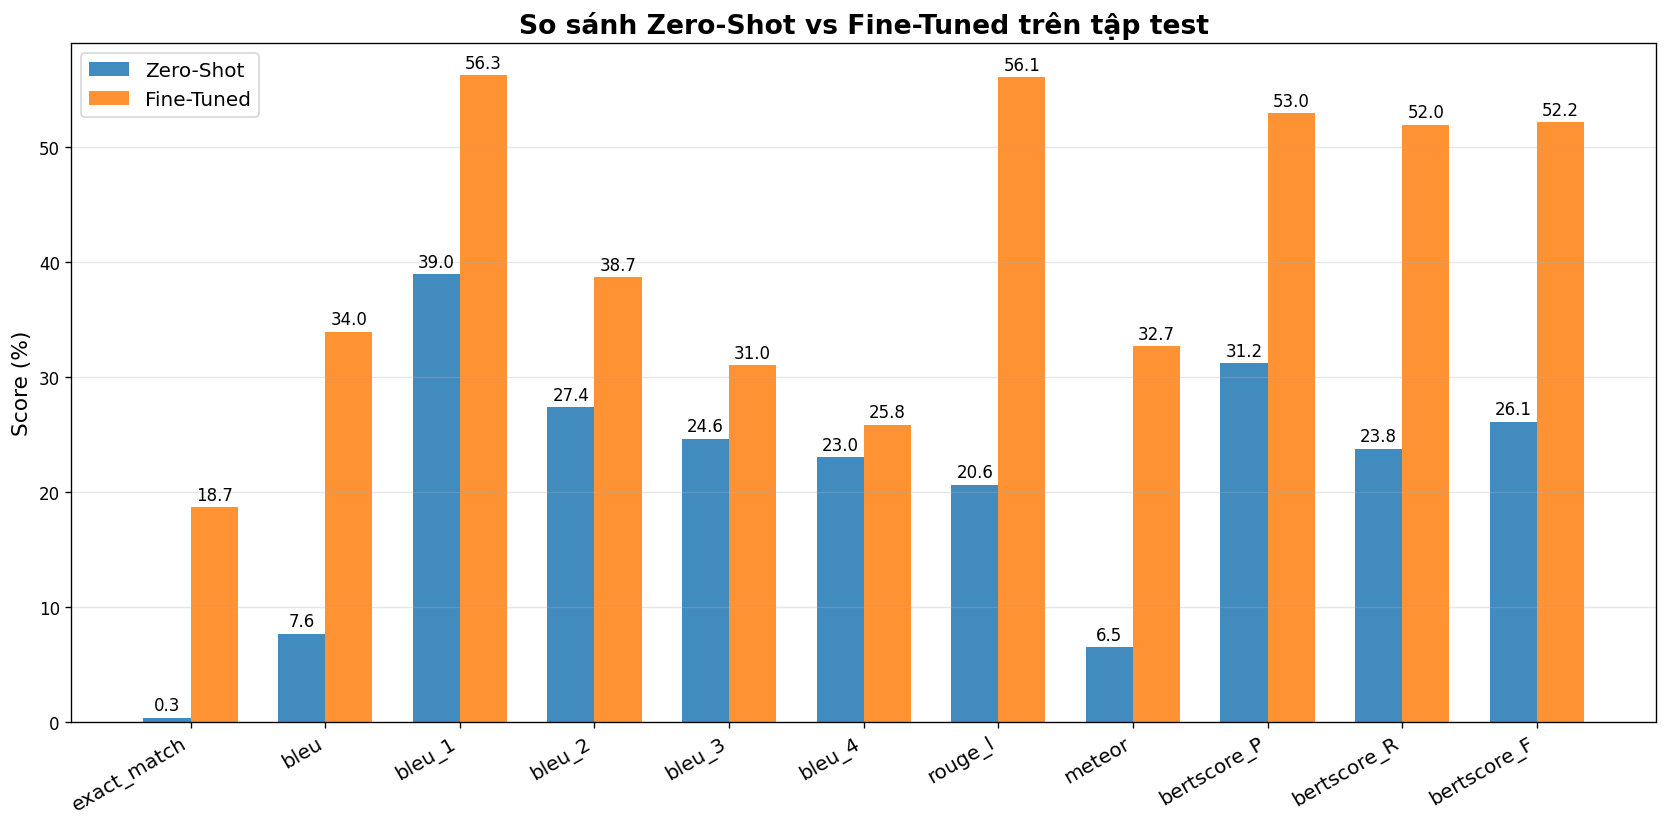

In [ ]:
# Vẽ biểu đồ so sánh trực quan giữa 2 mô hình: Zero-Shot và Fine-Tuned

# Giả sử metrics của 2 mô hình đã lưu ở biến metrics_zeroshot và metrics_finetuned
# metrics_zeroshot = {...}
# metrics_finetuned = {...}

labels = list(metrics_zs.keys())
zeroshot_scores = [metrics_zs[k] for k in labels]
finetuned_scores = [metrics_ft[k] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
bars1 = ax.bar(x - width/2, zeroshot_scores, width, label="Zero-Shot", color="#1f77b4", alpha=0.85)
bars2 = ax.bar(x + width/2, finetuned_scores, width, label="Fine-Tuned", color="#ff7f0e", alpha=0.85)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{h:.1f}", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{h:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, rotation=30, ha="right")
ax.set_ylabel("Score (%)", fontsize=13)
ax.set_title("So sánh Zero-Shot vs Fine-Tuned trên tập test", fontsize=16, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### So sánh DFO và SFT

In [ ]:
# CELL — Load DPO model từ HuggingFace & Đánh giá

#  1. Config 
DPO_REPO = "lpv30/DL-CK-DPO"
BASE_MODEL= "Salesforce/blip-vqa-base"
VAL_JSON = "data/test_en.json"   # file đã dịch VI→EN
DATA_ROOT = Path("")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE= 8
MAX_NEW_TOKENS = 50
print(f"Device: {DEVICE}")

#  2. Load processor + DPO model từ HF Hub 
print(f"\nLoading DPO model từ '{DPO_REPO}'...")
processor = BlipProcessor.from_pretrained(DPO_REPO)

base_model = BlipForQuestionAnswering.from_pretrained(BASE_MODEL)
model_dpo = PeftModel.from_pretrained(base_model, DPO_REPO)
model_dpo = model_dpo.to(DEVICE).eval()
print("Load DPO model thành công!")

#  3. Translator (EN → VI cho ground-truth refs) ─
en2vi = GoogleTranslator(source="en", target="vi")

def en_to_vi(text: str) -> str:
    try:
        return en2vi.translate(text) or text
    except Exception:
        return text

#  4. Sinh prediction trên val set ─
print(f"\nĐọc val set từ '{VAL_JSON}'...")
with open(VAL_JSON, "r", encoding="utf-8") as f:
    samples = json.load(f)

all_preds_vi_dpo, all_refs_vi_dpo = [], []

print(f"Đang inference {len(samples)} mẫu (batch_size={BATCH_SIZE})...")
for i in range(0, len(samples), BATCH_SIZE):
    batch_samples = samples[i : i + BATCH_SIZE]

    images= []
    questions = []   # tiếng Anh — BLIP cần EN
    refs_vi = []   # ground-truth tiếng Việt

    for s in batch_samples:
        img_path = DATA_ROOT / s["image_path"].replace("\\", "/")
        images.append(Image.open(img_path).convert("RGB"))
        questions.append(s.get("question_en", s["question"]))
        refs_vi.append(s.get("answer", ""))       # giữ nguyên VI gốc

    inputs = processor(
        images=images,
        text=questions,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64,
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model_dpo.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=4,
            repetition_penalty=2.0,
            length_penalty=1.2,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )

    for j, ids in enumerate(output_ids):
        ans_en = processor.decode(ids, skip_special_tokens=True)
        ans_vi = en_to_vi(ans_en)          # EN → VI để so với ground-truth VI
        all_preds_vi_dpo.append(ans_vi)

    all_refs_vi_dpo.extend(refs_vi)

    if (i // BATCH_SIZE + 1) % 20 == 0 or i + BATCH_SIZE >= len(samples):
        print(f"  {min(i + BATCH_SIZE, len(samples))}/{len(samples)} mẫu hoàn tất")

print(f"\nInference xong — {len(all_preds_vi_dpo)} predictions (DPO)")

#  6. Đánh giá với VQAEvaluator 
# Đảm bảo VQAEvaluator.py đã được upload / import đúng chỗ
import sys
sys.path.append("/content")          # điều chỉnh nếu file ở chỗ khác
from VQAEvaluator import VQAEvaluator

evaluator_dpo = VQAEvaluator(
    device=str(DEVICE),
    bertscore_model="vinai/phobert-base",   # PhoBERT cho tiếng Việt
    bertscore_layers=12,
    bleu_tokenize="char",                   # char-level phù hợp tiếng Việt
)

metrics_dpo, _, _ = evaluator_dpo.evaluate(
    model = model_dpo,
    loader = None,
    model_name = "BLIP-DPO (lpv30/DL-CK-DPO)",
    split_name = "val",
    preds = all_preds_vi_dpo,   # truyền thẳng pred/ref đã sinh ở trên
    refs = all_refs_vi_dpo,
    verbose= True,
)


Device: cuda

Loading DPO model từ 'lpv30/DL-CK-DPO'...


processor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--lpv30--DL-CK-DPO. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

adapter_model.safetensors:   0%|          | 0.00/30.8M [00:00<?, ?B/s]

Load DPO model thành công!

Đọc val set từ 'data/test_en.json'...
Đang inference 300 mẫu (batch_size=8)...
  160/300 mẫu hoàn tất
  300/300 mẫu hoàn tất

Inference xong — 300 predictions (DPO)

  Evaluating [BLIP-DPO (lpv30/DL-CK-DPO)] on [val]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Metric                    Value
  --------------------------------
  Exact Match (%)           19.00
  BLEU (corpus)             31.12
  BLEU-1                    50.59
  BLEU-2                    33.13
  BLEU-3                    25.96
  BLEU-4                    21.56
  ROUGE-L (%)               58.00
  METEOR (%)                35.32
  BERTScore-P (%)           51.62
  BERTScore-R (%)           53.73
  BERTScore-F (%)           52.37



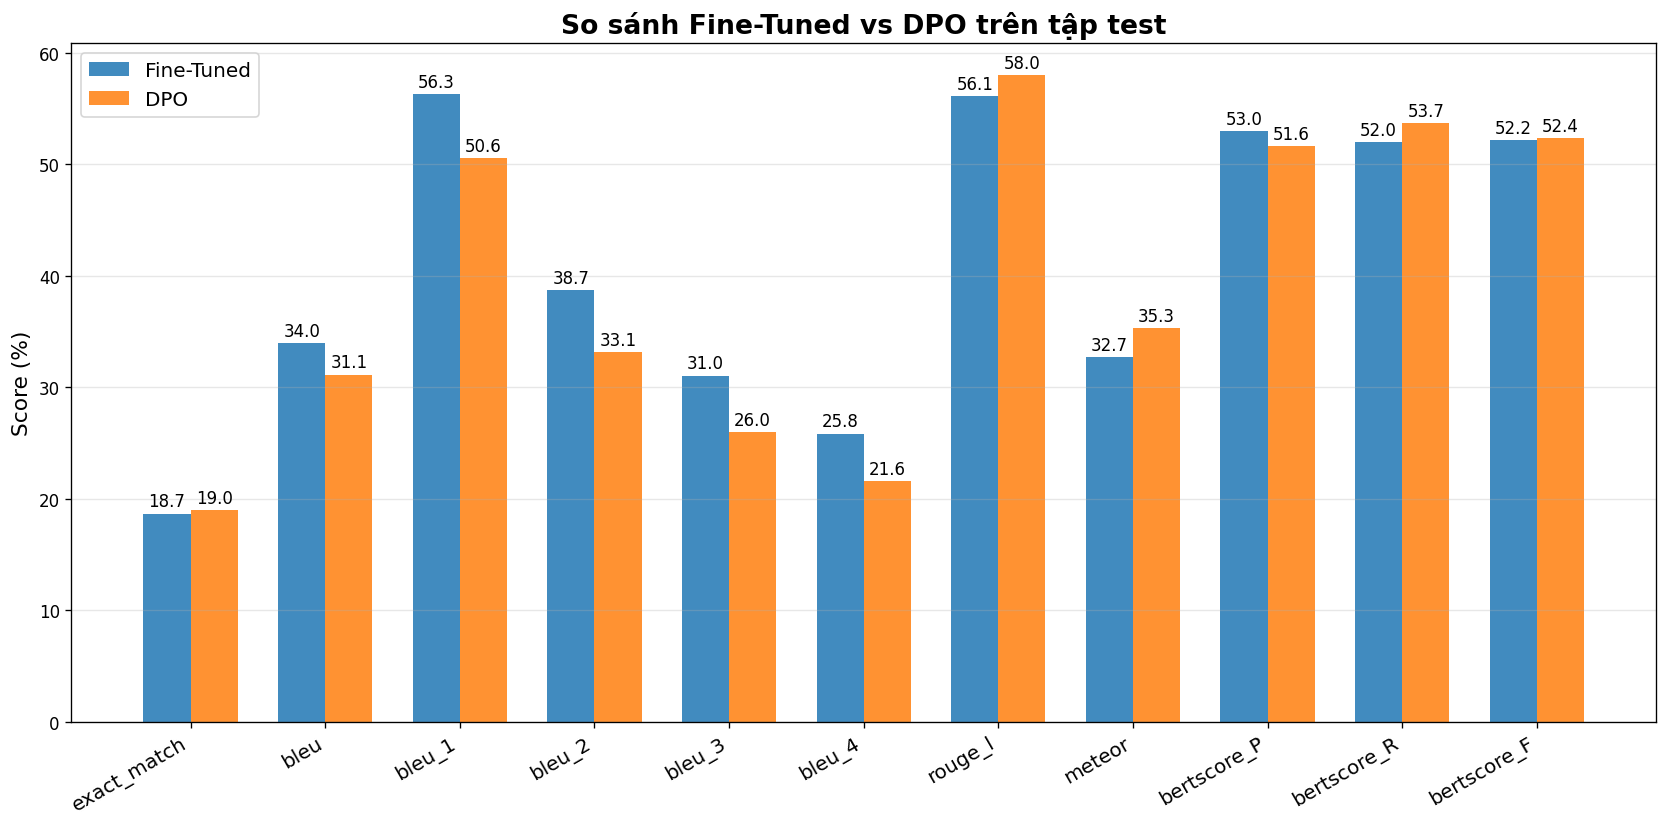

In [11]:

# Vẽ biểu đồ so sánh trực quan giữa 2 mô hình: Fine-Tuned và DPO

labels = list(metrics_ft.keys())
finetuned_scores = [metrics_ft[k] for k in labels]
dpo_scores = [metrics_dpo[k] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
bars1 = ax.bar(x - width/2, finetuned_scores, width, label="Fine-Tuned", color="#1f77b4", alpha=0.85)
bars2 = ax.bar(x + width/2, dpo_scores, width, label="DPO", color="#ff7f0e", alpha=0.85)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{h:.1f}", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{h:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, rotation=30, ha="right")
ax.set_ylabel("Score (%)", fontsize=13)
ax.set_title("So sánh Fine-Tuned vs DPO trên tập test", fontsize=16, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
